# Default run

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from contrailstereo import validation as V, vis
from contrailstereo.config import DEFAULT, load_paths
from contrailstereo.data.caliop import load_cases
from contrailstereo.geometry import apparent_surface_latlon
from contrailstereo.retrieve import load_frames, retrieve

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.width", 180)

CFG     = DEFAULT
#CFG     = DEFAULT.set(time_model="nominal", advect_truth=False)
SPLIT   = "dev"       # "dev" | "holdout" | "all"
N       = None        # None = every case in the split; an int = a random, fixed subset
MAX_VZA = None
QC      = ("ok",)
N_BOOT  = 2000
FIG_DIR = None        # e.g. load_paths().outputs / "figures" / SPLIT

# pre-registered operating points: (name, r gate, s_eff gate)
OPS = [("reference (r only)",       0.6, 0.0),
       ("confident",                0.65, 1.0),
       ("primary",                  0.7, 1.0)]
PRIMARY = dict(zip(["name", "r", "s"], OPS[2]))

paths = load_paths()
save = lambda name: (FIG_DIR / name) if FIG_DIR else None
if FIG_DIR:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"config {CFG.config_hash()}, time {CFG.time_model}, grid {CFG.grid_kind}, "
      f"ref {CFG.ref_sat}, split {SPLIT}, outputs {paths.outputs}")
if CFG.time_model == "lut" and not paths.abi_time.exists():
    raise FileNotFoundError(f"Time Model tables not found at {paths.abi_time}")

def on_map(truth):
    """Truth with lat/lon carried to the map time: use this when drawing on the height map."""
    return truth.assign(lat=truth.lat_adv.fillna(truth.lat), lon=truth.lon_adv.fillna(truth.lon))

config 1fc4f5cded, time lut, grid latlon, ref east, split dev, outputs /Users/lewisclark/Documents/python_work/stereo/outputs


## Run

In [2]:
import traceback
try:

    cases = V.select(load_cases(paths.collocations), SPLIT, n=N, max_vza=MAX_VZA,
                    sats=(CFG.sat_east, CFG.sat_west))
    run = V.run(cases, [V.Variant("base", CFG)], paths.outputs / "runs", paths=paths)["base"]
    ids = {c.id for c in cases}
    run = V.Run(run.variant, run.cases[run.cases.case_id.isin(ids)], run.profiles)
    by_id = {c.id: c for c in cases}
    if run.profiles.s_eff.isna().all():
        raise RuntimeError("this run has no s_eff: it was made before s_eff was stored")
    print(f"{len(run.cases)} cases ({SPLIT}), {len(run.profiles)} truth points, "
        f"{run.profiles.groupby(['case_id', 'contrail']).ngroups} contrails")
    run.cases.qc.value_counts().to_frame("cases")
except Exception:
    traceback.print_exc()

359 cases x 1 variants; 4 cases need work


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


  [1/4]         base scene   79 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes16/ABI-L2-CMIPF/2022/256/11


  [2/4]         base scene  495 qc=error    FileNotFoundError: noaa-goes16/ABI-L2-CMIPF/2022/256/11
  [3/4]         base scene  379 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22
  [4/4]         base scene  460 qc=error    ValueError: G16 channels not from one scan: domains {13: 'F', 15: 'C'}, times {13: Timestamp('2022-02-14 10:35:06.802976'), 15: Timestamp('2022-02-14 10:37:36.333179008')}
359 cases (dev), 15829 truth points, 649 contrails


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22
Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: G16 channels not from one scan: domains {13: 'F', 15: 'C'}, times {13: Timestamp('2022-02-14 10:35:06.802976'), 15: Timestamp('2022-02-14 10:37:36.333179008')}


## Per point

Per truth point, at each operating point. `yield` is the share of usable cases; `coverage` is the share of truth points **in usable cases** that pass both gates. `rmse_corr` removes a leave-one-case-out bias constant. `within` and `between` split it into matching precision inside a case and the spread of case offsets. Intervals come from resampling cases.

In [3]:
rows = []
for name, rg, sm in OPS:
    s = V.summary(run, rg, QC, n_boot=N_BOOT, s_min=sm)
    ci = lambda k: f"{s[k]:.3f} [{s[k + '_ci'][0]:.3f}, {s[k + '_ci'][1]:.3f}]"
    rows.append({"operating point": name, "r >": rg, "s_eff ≥": sm, "points": int(s["n"]),
                 "cases": s["n_cases_scored"], "yield": f"{s['yield']:.2f}",
                 "coverage": f"{s['coverage']:.2f}", "bias": ci("bias"),
                 "rmse_raw": f"{s['rmse_raw']:.3f}", "rmse_corr": ci("rmse_corr"),
                 "within": f"{s['within']:.3f}", "between": ci("between")})
pd.DataFrame(rows).set_index("operating point")

,r >,s_eff ≥,points,cases,yield,coverage,bias,rmse_raw,rmse_corr,within,between
operating point,,,,,,,,,,,
reference (r only),0.600,0.000,8938,204,0.67,0.78,"-0.262 [-0.313, -0.212]",0.596,"0.538 [0.464, 0.634]",0.390,"0.371 [0.319, 0.436]"
confident,0.650,1.000,6899,162,0.67,0.61,"-0.262 [-0.317, -0.208]",0.502,"0.431 [0.388, 0.479]",0.312,"0.296 [0.263, 0.338]"
primary,0.700,1.000,6415,147,0.67,0.56,"-0.266 [-0.322, -0.210]",0.500,"0.425 [0.380, 0.474]",0.303,"0.298 [0.263, 0.337]"


## Per contrail (comparable with Meijer et al. 2024)

A contrail is a contiguous run of CALIOP points (split at gaps > 5 km), assigned when the run is made. Its height is the median of its points passing the gates, and it's scored if at least 3 pass. Coverage is within the stereo domain (usable cases).

In [4]:
MIN_PTS = 3
rows = []
for name, rg, sm in OPS:
    c = V.contrail_summary(run, rg, QC, min_points=MIN_PTS, n_boot=N_BOOT, s_min=sm)
    ci = lambda k: f"{c[k]:.3f} [{c[k + '_ci'][0]:.3f}, {c[k + '_ci'][1]:.3f}]"
    rows.append({"operating point": name, "r >": rg, "s_eff ≥": sm,
                 "contrails": f"{c['n_scored']}/{c['n_contrails']}",
                 "coverage": f"{c['contrail_coverage']:.2f}", "bias": ci("bias"),
                 "RMSE raw": ci("rmse_raw"), "RMSE corr": ci("rmse_corr")})
rows += [{"operating point": "Meijer et al. 2024 CNN", "coverage": "all", "RMSE raw": "0.570"},
         {"operating point": "Google CNN (attribution-trained)", "coverage": "all",
          "RMSE raw": "0.789"}]
pd.DataFrame(rows).set_index("operating point").fillna("")

,r >,s_eff ≥,contrails,coverage,bias,RMSE raw,RMSE corr
operating point,,,,,,,
reference (r only),0.600,0.000,356/458,0.78,"-0.254 [-0.313, -0.191]","0.620 [0.514, 0.739]","0.567 [0.454, 0.689]"
confident,0.650,1.000,268/458,0.59,"-0.267 [-0.314, -0.221]","0.443 [0.402, 0.484]","0.355 [0.320, 0.387]"
primary,0.700,1.000,247/458,0.54,"-0.269 [-0.321, -0.217]","0.448 [0.398, 0.491]","0.360 [0.320, 0.392]"
Meijer et al. 2024 CNN,,,,all,,0.570,
Google CNN (attribution-trained),,,,all,,0.789,


## Sensitivity to the two gates, per contrail

Every combination of r and `s_eff` gates: the effect of each with the other held fixed, and the best combination at each coverage (the frontier) against the r-only curve. The printout compares them at matched coverage (±0.05). **Selection happens on dev only**; on holdout this is a description, not a menu.

coverage ~0.5: r only 0.482 (r>0.80, cov 0.50) | best 0.340 (r>0.75, s_eff≥1.00, cov 0.48) | gain +0.142 km
coverage ~0.6: r only 0.486 (r>0.75, cov 0.60) | best 0.355 (r>0.65, s_eff≥1.00, cov 0.59) | gain +0.131 km
coverage ~0.7: r only 0.482 (r>0.65, cov 0.72) | best 0.419 (r>0.65, s_eff≥0.75, cov 0.68) | gain +0.063 km


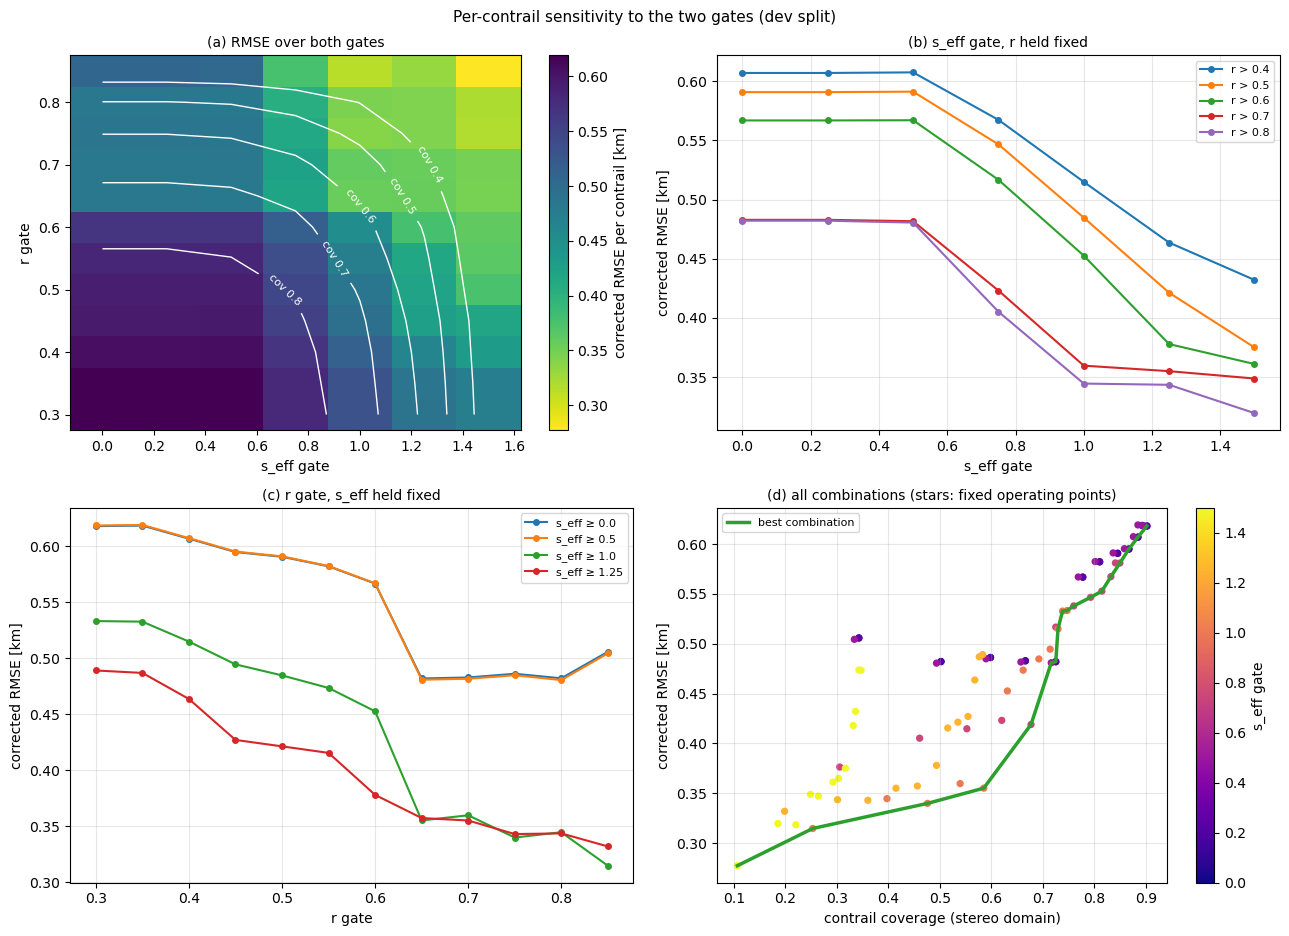

In [5]:
R_GRID = np.round(np.arange(0.30, 0.86, 0.05), 2)
S_GRID = np.round(np.arange(0.0, 1.51, 0.25), 2)
sw = pd.DataFrame([dict(r=rg, s_min=sm, **{k: v for k, v in V.contrail_summary(
    run, rg, QC, min_points=MIN_PTS, n_boot=0, s_min=sm).items()
    if k in ("contrail_coverage", "n_scored", "bias", "rmse_raw", "rmse_corr")})
    for sm in S_GRID for rg in R_GRID]).rename(columns={"contrail_coverage": "coverage"})
piv = lambda col: sw.pivot(index="r", columns="s_min", values=col)

fig, axs = plt.subplots(2, 2, figsize=(13, 9.5))
ax = axs[0, 0]
im = ax.pcolormesh(S_GRID, R_GRID, piv("rmse_corr").values, shading="nearest", cmap="viridis_r")
fig.colorbar(im, ax=ax, label="corrected RMSE per contrail [km]")
cs = ax.contour(S_GRID, R_GRID, piv("coverage").values, levels=(0.4, 0.5, 0.6, 0.7, 0.8),
                colors="w", linewidths=1)
ax.clabel(cs, fmt=lambda v: f"cov {v:.1f}", fontsize=8)
ax.set_xlabel("s_eff gate"); ax.set_ylabel("r gate"); ax.set_title("(a) RMSE over both gates", fontsize=10)
ax = axs[0, 1]
for rg in (0.4, 0.5, 0.6, 0.7, 0.8):
    g_ = sw[sw.r == rg]; ax.plot(g_.s_min, g_.rmse_corr, "o-", ms=4, label=f"r > {rg}")
ax.set_xlabel("s_eff gate"); ax.set_ylabel("corrected RMSE [km]")
ax.set_title("(b) s_eff gate, r held fixed", fontsize=10); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axs[1, 0]
for sm in (0.0, 0.5, 1.0, 1.25):
    g_ = sw[sw.s_min == sm]; ax.plot(g_.r, g_.rmse_corr, "o-", ms=4, label=f"s_eff ≥ {sm}")
ax.set_xlabel("r gate"); ax.set_ylabel("corrected RMSE [km]")
ax.set_title("(c) r gate, s_eff held fixed", fontsize=10); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axs[1, 1]
sc = ax.scatter(sw.coverage, sw.rmse_corr, c=sw.s_min, cmap="plasma", s=18)
fig.colorbar(sc, ax=ax, label="s_eff gate")
r0 = sw[sw.s_min == 0].sort_values("coverage")
#ax.plot(r0.coverage, r0.rmse_corr, "k--", lw=1.5, label="r gate only")
pts_ = sw.dropna(subset=["rmse_corr"]).sort_values("coverage", ascending=False)
front = pts_[pts_.rmse_corr == pts_.rmse_corr.cummin()]
ax.plot(front.coverage, front.rmse_corr, "-", color="C2", lw=2.5, label="best combination")
#for name, rg, sm in OPS:
#    o = sw[(sw.r == rg) & (sw.s_min == sm)]
#    ax.plot(o.coverage, o.rmse_corr, "*", ms=14, mec="k", mfc="w", zorder=5)
#    ax.annotate(name, (o.coverage.iloc[0], o.rmse_corr.iloc[0]), fontsize=7,
#                xytext=(5, 5), textcoords="offset points")
ax.set_xlabel("contrail coverage (stereo domain)"); ax.set_ylabel("corrected RMSE [km]")
ax.set_title("(d) all combinations (stars: fixed operating points)", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle(f"Per-contrail sensitivity to the two gates ({SPLIT} split)", fontsize=11)
fig.tight_layout()
if FIG_DIR:
    fig.savefig(save("gate_sensitivity.pdf"), bbox_inches="tight")

def near(d, target, tol=0.05):
    d = d.dropna(subset=["rmse_corr"]); d = d[(d.coverage - target).abs() <= tol]
    return None if d.empty else d.loc[d.rmse_corr.idxmin()]
for target in (0.5, 0.6, 0.7):
    a, b = near(sw[sw.s_min == 0], target), near(sw, target)
    print(f"coverage ~{target:.1f}: " + ("no grid point within ±0.05" if a is None or b is None else
          f"r only {a.rmse_corr:.3f} (r>{a.r:.2f}, cov {a.coverage:.2f}) | best {b.rmse_corr:.3f} "
          f"(r>{b.r:.2f}, s_eff≥{b.s_min:.2f}, cov {b.coverage:.2f}) | gain {a.rmse_corr - b.rmse_corr:+.3f} km"))

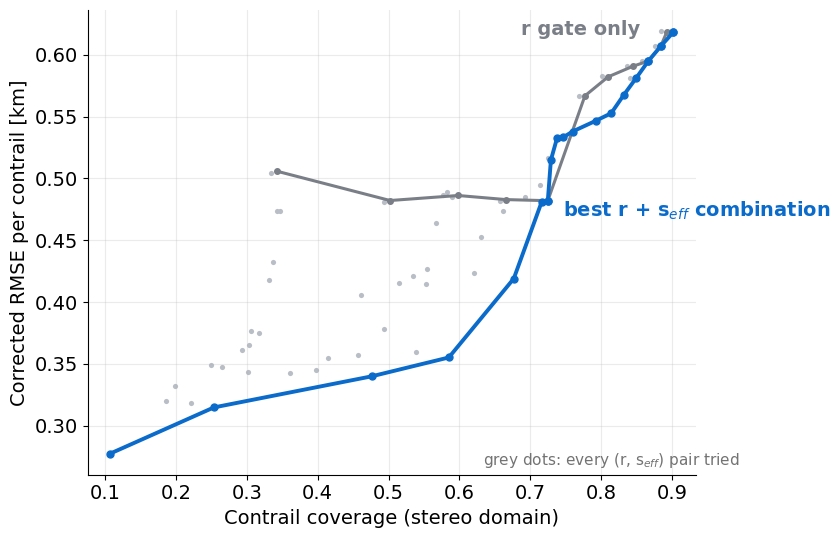

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# ---------------------------------------------------------------- presentation version of panel (d)
def gate_tradeoff_panel(sw, targets=(0.5, 0.6, 0.7), ax=None, save=None,
                        c_r="#7a7f87", c_best="#0b6bcb", c_all="#b9bec6"):
    """Coverage vs corrected RMSE.  sw: one row per (r, s_min) with columns
    coverage, rmse_corr (and r, s_min).  Grey = r gate only; blue = best r/s_eff combination
    at each coverage (the Pareto front); the gap between them is what the s_eff gate buys."""
    d = sw.dropna(subset=["coverage", "rmse_corr"])
    r_only = d[d.s_min == 0].sort_values("coverage")
    # Pareto front over ALL combinations: no other combination has more coverage AND lower RMSE
    by_cov = d.sort_values("coverage", ascending=False)
    front = by_cov[by_cov.rmse_corr == by_cov.rmse_corr.cummin()].sort_values("coverage")

    own = ax is None
    if own:
        plt.rcParams.update({"font.size": 14, "axes.spines.top": False, "axes.spines.right": False})
        fig, ax = plt.subplots(figsize=(8.5, 5.6))
    ax.scatter(d.coverage, d.rmse_corr, s=14, color=c_all, zorder=1, lw=0)            # every (r, s_eff) pair, quiet
    ax.plot(r_only.coverage, r_only.rmse_corr, "-o", color=c_r, lw=2.2, ms=4, zorder=3)
    ax.plot(front.coverage, front.rmse_corr, "-o", color=c_best, lw=2.8, ms=5, zorder=4)

    # gain at chosen coverages: a bracket between the two curves, value to its left

    # direct labels, away from where the two curves meet
    xr = np.quantile(r_only.coverage, 0.75); xb = np.quantile(front.coverage, 0.35)
    ax.annotate("r gate only", (xr, np.interp(xr, r_only.coverage, r_only.rmse_corr)), xytext=(-8, 16),
                textcoords="offset points", ha="right", color=c_r, fontsize=14, fontweight="bold")
    ax.annotate("best r + s$_{eff}$ combination", (xb, np.interp(xb, front.coverage, front.rmse_corr)),
                xytext=(10, -22), textcoords="offset points", ha="left", color=c_best, fontsize=14, fontweight="bold")
    ax.text(0.65, 0.02, "grey dots: every (r, s$_{eff}$) pair tried", transform=ax.transAxes, color="0.45", fontsize=11)
    ax.set_xlabel("Contrail coverage (stereo domain)")
    ax.set_ylabel("Corrected RMSE per contrail [km]")
    ax.grid(alpha=0.25); ax.margins(x=0.04)
    if own:
        fig.tight_layout()
        if save: fig.savefig(save, dpi=200, bbox_inches="tight")
        return fig


fig = gate_tradeoff_panel(sw, targets=(0.5, 0.6, 0.7), save="gate_tradeoff.pdf")

## Figures at the primary operating point

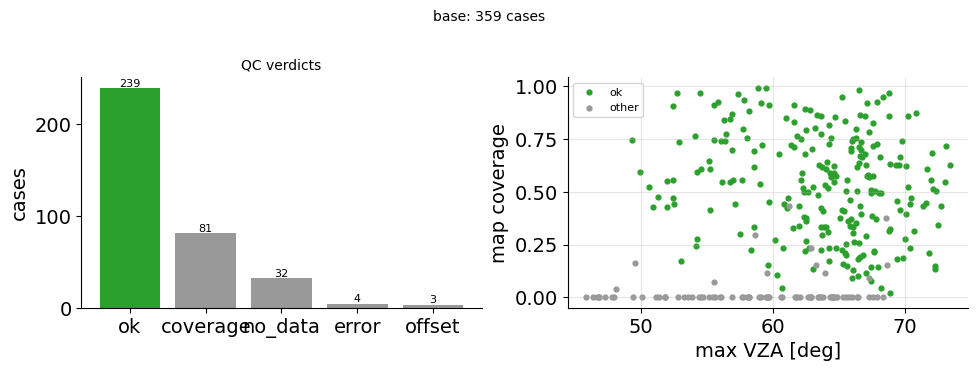

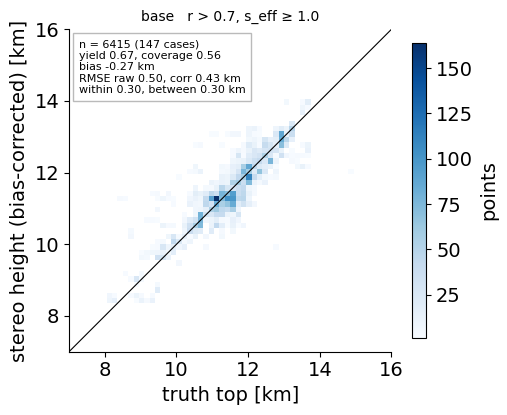

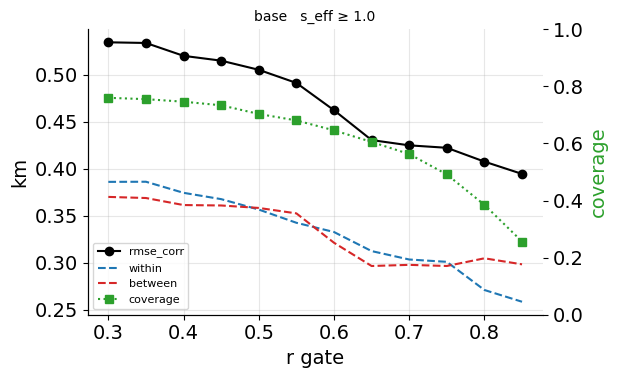

In [7]:
vis.run_overview(run, save=save("overview.pdf"))
vis.truth_scatter(run, PRIMARY["r"], QC, s_min=PRIMARY["s"], save=save("truth_scatter.pdf"))
vis.gate_tradeoff(run, qc=QC, s_min=PRIMARY["s"], save=save("gate_tradeoff.pdf"));

## Where the error comes from

Cases ranked by their share of the squared corrected error at the primary operating point, with their median `s_eff`. A few cases dominating means the headline RMSE is fragile, so read it together with the robust numbers below.

In [8]:
ct = V.case_table(run, PRIMARY["r"], QC, s_min=PRIMARY["s"])
med_s = run.profiles.groupby("case_id").s_eff.median()
ct["s_eff_median"] = ct.case_id.map(med_s)
ctab = V.contrail_table(run, PRIMARY["r"], QC, min_points=MIN_PTS, s_min=PRIMARY["s"])
e = ctab[ctab.scored].err - ctab[ctab.scored].err.mean()
print(f"top 5 cases carry {ct.sse_share.head(5).sum():.0%} of squared error; "
      f"{(ct.offset.abs() > 1).sum()} cases with |offset| > 1 km")
print(f"per contrail, bias-removed: median |error| {e.abs().median():.3f} km, "
      f"within 0.5 km {(e.abs() <= 0.5).mean():.0%}, within 1 km {(e.abs() <= 1).mean():.0%}")
ct.head(15)

top 5 cases carry 24% of squared error; 2 cases with |offset| > 1 km
per contrail, bias-removed: median |error| 0.221 km, within 0.5 km 83%, within 1 km 100%


,case_id,n,bias,sd,offset,sse_share,scene,qc,vza_max,map_coverage,s_eff_median
0,OR_ABI-L2-MCMIPC-M6_G16_s20211521101162_e20211...,117,-0.526,0.749,-0.268,0.064,25,ok,70.850,0.872,1.889
1,OR_ABI-L2-MCMIPC-M3_G16_s20190112127175_e20190...,68,0.367,0.768,0.630,0.058,7,ok,72.104,0.513,2.189
2,OR_ABI-L2-MCMIPC-M6_G16_s20210942141167_e20210...,66,0.386,0.680,0.650,0.050,108,ok,62.789,0.890,1.546
3,OR_ABI-L2-MCMIPC-M3_G16_s20190812122191_e20190...,107,0.023,0.560,0.285,0.036,38,ok,61.614,0.912,1.492
4,OR_ABI-L2-MCMIPC-M3_G16_s20190150937171_e20190...,94,-0.702,0.445,-0.446,0.032,42,ok,54.589,0.609,1.095
5,OR_ABI-L2-MCMIPF-M6_G16_s20191382120358_e20191...,101,-0.383,0.563,-0.125,0.029,23,ok,61.997,0.338,1.878
6,OR_ABI-L2-MCMIPC-M3_G16_s20190232047167_e20190...,74,-0.602,0.555,-0.345,0.027,31,ok,67.415,0.508,1.177
7,OR_ABI-L2-MCMIPC-M3_G16_s20190631027130_e20190...,95,0.185,0.364,0.447,0.027,53,ok,67.272,0.783,2.105
8,OR_ABI-L2-MCMIPC-M6_G16_s20191612106471_e20191...,58,0.163,0.585,0.425,0.026,29,ok,59.469,0.993,1.640
9,OR_ABI-L2-MCMIPC-M6_G16_s20213322201177_e20213...,52,-0.991,0.149,-0.737,0.025,73,ok,71.686,0.606,1.652


## Inspect a case

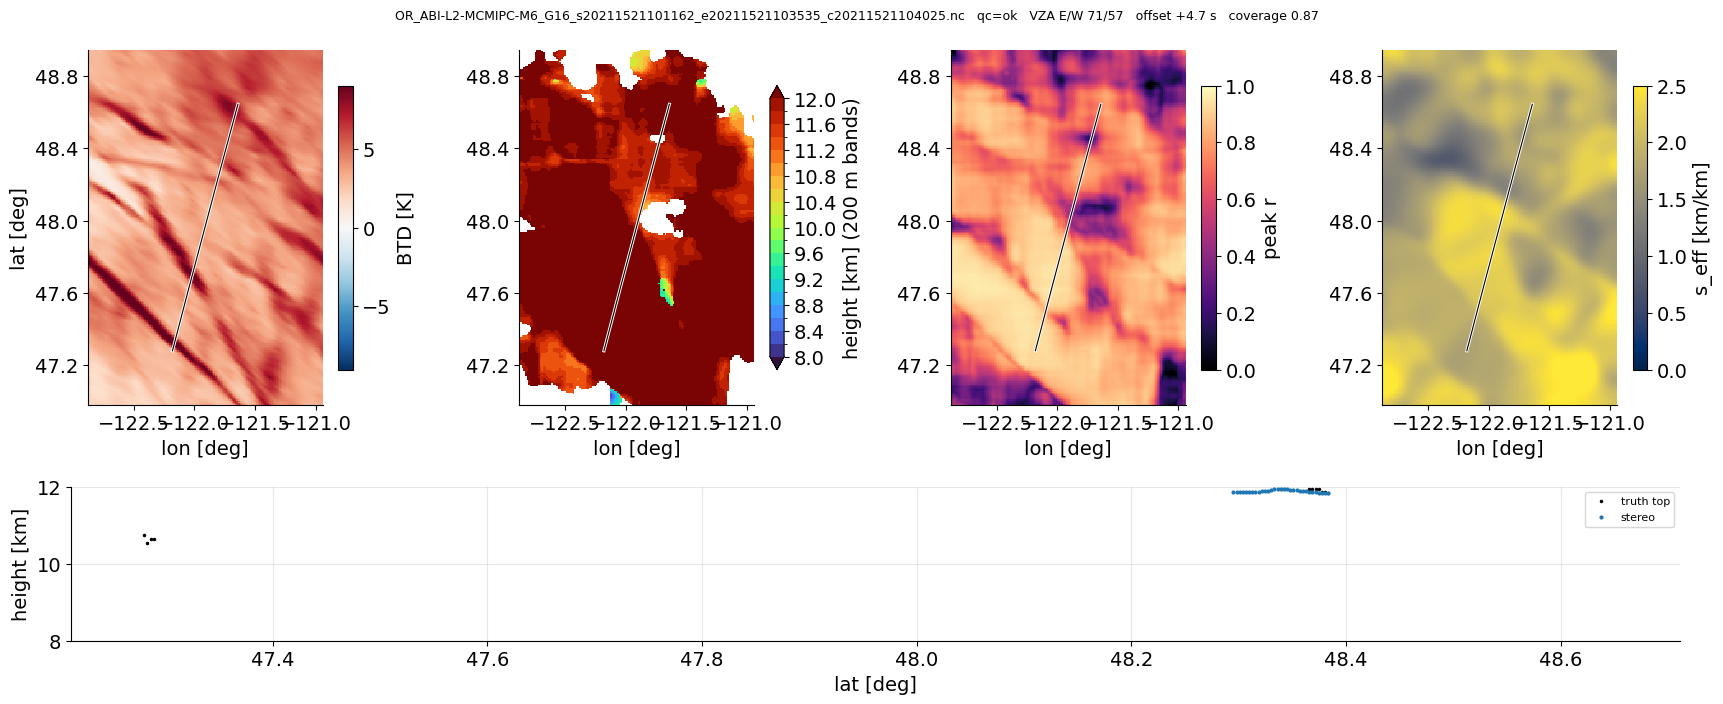

In [9]:
SCENE = None
row = ct.iloc[0] if SCENE is None else run.cases[run.cases.scene == SCENE].iloc[0]
case = by_id[row.case_id]

cfg_nb = CFG.set(stripe_mask=False)
frames = load_frames(case, cfg_nb, paths)          
res = retrieve(case, cfg_nb, paths, frames=frames)

#frames = load_frames(case, CFG, paths)
#res = retrieve(case, CFG, paths, frames=frames)
truth = V.attach_truth(res, case)
h_ref = res.diag.get("s_eff_h_ref", 11.0)
E = frames[(CFG.sat_east, 0)]
alat, alon = apparent_surface_latlon(res.grid.lat, res.grid.lon, h_ref * 1e3, E.sat_lon)
vis.map_panel(res, truth, btd=E.view(alat, alon), save=save(f"scene_{case.meta['scene']}.pdf"), h_lims=[8.0,12.0])
plt.show()

{'stripe_max': 2.6991756291152798, 'stripe_rows': 42, 'offset_s': 4.7378599999999995, 'vza_east': 70.8499352898865, 'vza_west': 56.982270172340215, 'map_coverage': 0.8721518177163339}


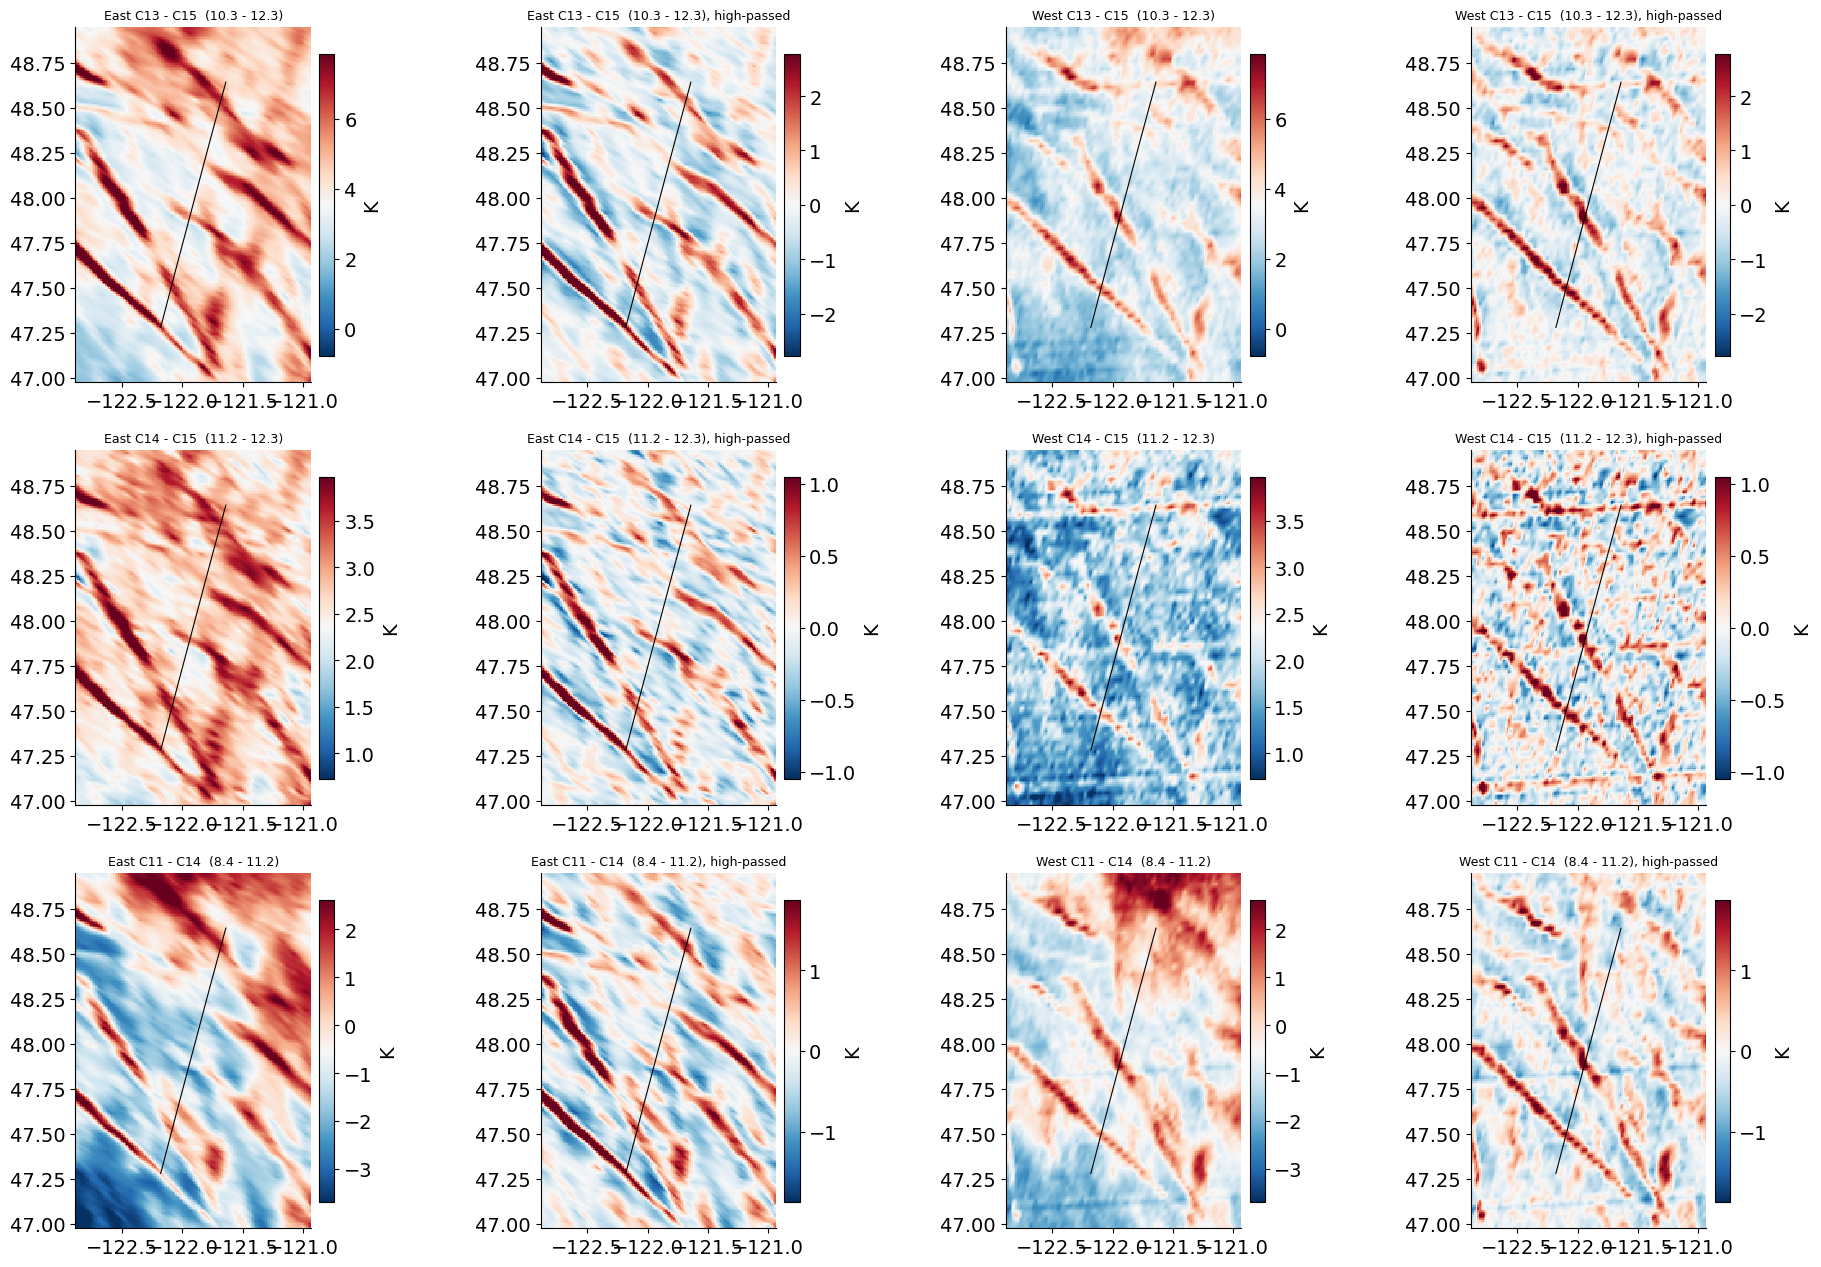

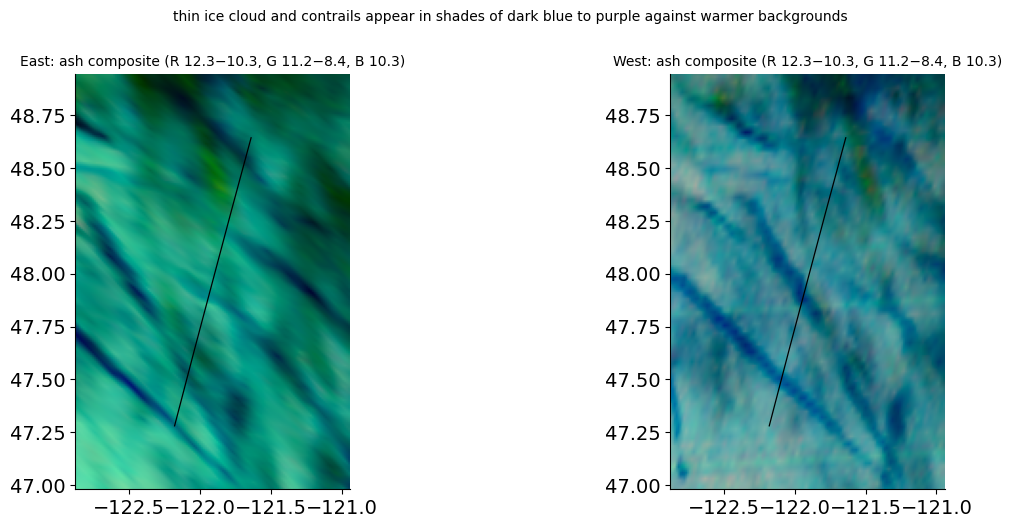

In [10]:
# ---- Channel comparison: differences and the ash recipe, raw and high-passed -------
from contrailstereo.data.goes import fetch_channels
from contrailstereo.prep import btd_view, highpass
from contrailstereo.geometry import km_filters
CH = (11, 13, 14, 15)          # 8.4, 10.3, 11.2, 12.3 um
g = res.grid
sig = km_filters(g, CFG)[0]
d_ = res.diag
print({k: d_.get(k) for k in ("stripe_max", "stripe_rows", "offset_s",
                              "vza_east", "vza_west", "map_coverage")})

DS = {}
for sat in (CFG.sat_east, CFG.sat_west):
    DS[sat], _ = fetch_channels(sat, CH, case.time, paths.goes_cache)

def bt(sat, ch):                                  # single channel on the grid [K]
    ds = DS[sat][ch]; zero = ds.copy(); zero["CMI"] = ds["CMI"] * 0
    return btd_view(ds, zero)(g.lat, g.lon)

def diff(sat, a, b):                              # channel difference on the grid [K]
    return btd_view(DS[sat][a], DS[sat][b])(g.lat, g.lon)

FIELDS = [("C13 - C15  (10.3 - 12.3)", lambda s: diff(s, 13, 15)),
          ("C14 - C15  (11.2 - 12.3)", lambda s: diff(s, 14, 15)),
          ("C11 - C14  (8.4 - 11.2)",  lambda s: diff(s, 11, 14))]

fig, axs = plt.subplots(len(FIELDS), 4, figsize=(19, 4.3 * len(FIELDS)), squeeze=False)
for r_, (lab, fn) in enumerate(FIELDS):
    Zs = {s: fn(s) for s in (CFG.sat_east, CFG.sat_west)}
    raw = np.concatenate([Z[np.isfinite(Z)].ravel() for Z in Zs.values()])
    med = np.median(raw); vr = np.percentile(np.abs(raw - med), 99)
    hp = {s: highpass(Z, sig) for s, Z in Zs.items()}
    allhp = np.concatenate([Z[np.isfinite(Z)].ravel() for Z in hp.values()])
    vh = np.percentile(np.abs(allhp), 99)
    panels = [(f"East {lab}", Zs[CFG.sat_east], med, vr), (f"East {lab}, high-passed", hp[CFG.sat_east], 0, vh),
              (f"West {lab}", Zs[CFG.sat_west], med, vr), (f"West {lab}, high-passed", hp[CFG.sat_west], 0, vh)]
    for ax, (t_, Z, c_, v_) in zip(axs[r_], panels):
        pm = ax.pcolormesh(g.lon, g.lat, Z, cmap="RdBu_r", vmin=c_ - v_, vmax=c_ + v_, shading="auto")
        fig.colorbar(pm, ax=ax, shrink=0.85, pad=0.02, label="K")
        ax.plot(truth.lon, truth.lat, "k-", lw=0.8)
        ax.set_aspect(1 / np.cos(np.deg2rad(g.bbox.center[0])))
        ax.set_title(t_, fontsize=9)
fig.tight_layout()

# ---- ash composite: R = 12.3-10.3, G = 11.2-8.4, B = 10.3 -------------------------
ASH = dict(R=((15, 13), (-4.0, 2.0), 1.0), G=((14, 11), (-4.0, 5.0), 1.0),
           B=((13, None), (243.0, 303.0), 1.0))
def ash_rgb(sat):
    ch = {}
    for c_, ((a, b), (lo, hi), gam) in ASH.items():
        Z = bt(sat, a) if b is None else diff(sat, a, b)
        ch[c_] = np.clip((Z - lo) / (hi - lo), 0, 1) ** (1 / gam)
    rgb = np.dstack([ch["R"], ch["G"], ch["B"]])
    rgb[~np.isfinite(rgb).all(-1)] = 1.0
    return rgb

fig, axs = plt.subplots(1, 2, figsize=(13, 5.4))
for ax, (sat, lab) in zip(axs, ((CFG.sat_east, "East"), (CFG.sat_west, "West"))):
    ax.imshow(ash_rgb(sat), origin="lower",
              extent=[g.lon1d[0], g.lon1d[-1], g.lat1d[0], g.lat1d[-1]], aspect="auto")
    ax.plot(truth.lon, truth.lat, "k-", lw=0.9)
    ax.set_aspect(1 / np.cos(np.deg2rad(g.bbox.center[0])))
    ax.set_title(f"{lab}: ash composite (R 12.3−10.3, G 11.2−8.4, B 10.3)", fontsize=10)
fig.suptitle("thin ice cloud and contrails appear in shades of dark blue to purple "
             "against warmer backgrounds", fontsize=10)
fig.tight_layout()

# wHy failr

In [3]:
# ---- Ablation: time model x truth advection, on a few cases ------------------------
# Needs (from the cells above): CFG, paths, V, vis, PRIMARY, run, by_id, save.
# Two retrievals per case (time_model nominal / lut). Truth advection is applied
# afterwards, so each retrieval is shown with raw and with advected truth.
# nominal + raw truth = the original behaviour.
from contrailstereo.geometry import apparent_surface_latlon
from contrailstereo.retrieve import load_frames, retrieve, ref_key

SCENES      = [243,49,108]                       # scene ids to inspect (as in "Case 41" above)
CASES       = None                       # or a list of Case objects, overriding SCENES
TIME_MODELS = ("nominal", "lut")
ADVECT      = (False, True)              # truth: raw positions / carried to the map time
H_LIMS      = [8.0, 12.0]
SHOW_MAPS   = True                       # False = table only

if CASES is None:
    CASES = [by_id[run.cases[run.cases.scene == s].iloc[0].case_id] for s in SCENES]

"""rows = []
for case in CASES:
    sc = case.meta.get("scene", case.id)
    for tm in TIME_MODELS:
        cfg = CFG.set(time_model=tm)
        try:
            frames = load_frames(case, cfg, paths)
            res = retrieve(case, cfg, paths, frames=frames)
        except Exception as e:                                         # noqa: BLE001
            print(f"scene {sc} | time_model={tm}: {type(e).__name__}: {e}")
            continue
        wind_used = res.wind is not None
        for adv in ADVECT:
            label = f"scene {sc} | time_model={tm} | truth {'advected' if adv else 'raw'}"
            truth = V.attach_truth(res, case, advect=adv)
            ok = truth.r > PRIMARY["r"]
            err = (truth.h - truth.top_km)[ok]
            rows.append(dict(scene=sc, time_model=tm, truth="advected" if adv else "raw",
                             qc=res.qc, offset_s=res.diag.get("offset_s"),
                             wind=wind_used, moved_km=truth.disp_km.median(),
                             n_pts=int(ok.sum()), bias=err.mean(),
                             rmse=np.sqrt((err ** 2).mean()) if len(err) else np.nan,
                             rmse_corr=err.std(ddof=0) if len(err) else np.nan,
                             map_cov=res.diag.get("map_coverage")))
            if not SHOW_MAPS or res.height is None:
                continue
            # the map overlay uses the positions the points were sampled at
            on_map = truth.assign(lat=truth.lat_adv.fillna(truth.lat),
                                  lon=truth.lon_adv.fillna(truth.lon)) if adv else truth
            F = frames[ref_key(cfg)]
            h_ref = res.diag.get("s_eff_h_ref", 11.0)
            alat, alon = apparent_surface_latlon(res.grid.lat, res.grid.lon, h_ref * 1e3, F.sat_lon)
            vis.map_panel(res, on_map, btd=F.view(alat, alon), title=label, h_lims=H_LIMS,
                          save=save(f"ablate_{sc}_{tm}_{'adv' if adv else 'raw'}.pdf"))
            plt.show()

pd.DataFrame(rows).set_index(["scene", "time_model", "truth"])"""

'rows = []\nfor case in CASES:\n    sc = case.meta.get("scene", case.id)\n    for tm in TIME_MODELS:\n        cfg = CFG.set(time_model=tm)\n        try:\n            frames = load_frames(case, cfg, paths)\n            res = retrieve(case, cfg, paths, frames=frames)\n        except Exception as e:                                         # noqa: BLE001\n            print(f"scene {sc} | time_model={tm}: {type(e).__name__}: {e}")\n            continue\n        wind_used = res.wind is not None\n        for adv in ADVECT:\n            label = f"scene {sc} | time_model={tm} | truth {\'advected\' if adv else \'raw\'}"\n            truth = V.attach_truth(res, case, advect=adv)\n            ok = truth.r > PRIMARY["r"]\n            err = (truth.h - truth.top_km)[ok]\n            rows.append(dict(scene=sc, time_model=tm, truth="advected" if adv else "raw",\n                             qc=res.qc, offset_s=res.diag.get("offset_s"),\n                             wind=wind_used, moved_km=truth.disp_k

In [4]:
# ---- All cases, paired: original vs new, per point and per contrail --------------------
# Needs (from the cells above): CFG, paths, V, cases, ids, run, PRIMARY, QC, N_BOOT, MIN_PTS.
# Arms:  nom_raw = the original (nominal times, raw truth)
#        lut_raw = new time model, raw truth
#        lut_adv = `run` from the Run cell (new defaults: lut + advected truth)
# Pairs are scored on the SAME cases and the SAME points/contrails, so the case sets
# cannot differ between arms. delta = second - first; [lo, hi] is a case bootstrap CI.
ARMS = {"nom_raw": CFG.set(time_model="nominal", advect_truth=False),
        "lut_raw": CFG.set(time_model="lut", advect_truth=False)}
# add "nom_adv": CFG.set(time_model="nominal", advect_truth=True) if you want it
#   (with a small nominal offset no wind is loaded, so truth is then not advected)
PAIRS = [("nom_raw", "lut_raw", "time model"),
         ("lut_raw", "lut_adv", "truth advection"),
         ("nom_raw", "lut_adv", "both")]

done = V.run(cases, [V.Variant(n, c) for n, c in ARMS.items()],
             paths.outputs / "runs", paths=paths)
runs = {n: V.Run(r.variant, r.cases[r.cases.case_id.isin(ids)], r.profiles)
        for n, r in done.items()}
runs["lut_adv"] = run
gate, smin = PRIMARY["r"], PRIMARY["s"]
fmt = lambda a, b, lo, hi, call: f"{a:.3f} -> {b:.3f}  d{b - a:+.3f} [{lo:+.3f}, {hi:+.3f}] {call}"



359 cases x 2 variants; 4 cases need work


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


  [1/4]      nom_raw scene   79 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


  [1/4]      lut_raw scene   79 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


...

Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes16/ABI-L2-CMIPF/2022/256/11


  [2/4]      lut_raw scene  495 qc=error    FileNotFoundError: noaa-goes16/ABI-L2-CMIPF/2022/256/11


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22


  [3/4]      nom_raw scene  379 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22
  [3/4]      lut_raw scene  379 qc=error    FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22
  [4/4]      nom_raw scene  460 qc=error    ValueError: G16 channels not from one scan: domains {13: 'F', 15: 'C'}, times {13: Timestamp('2022-02-14 10:35:06.802976'), 15: Timestamp('2022-02-14 10:37:36.333179008')}
  [4/4]      lut_raw scene  460 qc=error    ValueError: G16 channels not from one scan: domains {13: 'F', 15: 'C'}, times {13: Timestamp('2022-02-14 10:35:06.802976'), 15: Timestamp('2022-02-14 10:37:36.333179008')}


Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22
Traceback (most recent call last):
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 272, in run
    raise frames[sig]
  File "/Users/lewisclark/Documents/python_work/stereo/src/contrailstereo/validation.py", line 268, in run
    frames[sig] = frame_loader(case, v.cfg, paths)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: G16 channels not from one scan: domains {13: 'F', 15: 'C'}, times {13: Timestamp('2022-02-14 10:35:06.802976'), 15: Timestamp('2022-02-14 10:37:36.333179008')}
Traceback (most recent cal

In [5]:
MIN_PTS = 3

In [7]:
# ---- (re)build the arms on the FULL split, whatever `cases` / `ids` hold now ------------------
cases_all = V.select(load_cases(paths.collocations), SPLIT, n=None, max_vza=MAX_VZA,
                     sats=(CFG.sat_east, CFG.sat_west))
#keep = {c.id for c in cases_all}
#done = V.run(cases_all, [V.Variant("base", CFG)] + [V.Variant(n, c) for n, c in ARMS.items()],
#             paths.outputs / "runs", paths=paths)          # resumes: only missing work is run
#runs = {("lut_adv" if n == "base" else n): V.Run(r.variant, r.cases[r.cases.case_id.isin(keep)], r.profiles)
#        for n, r in done.items()}
#print(f"{len(keep)} cases in split {SPLIT!r}; cases per arm: "
#      + ", ".join(f"{n} {len(r.cases)}" for n, r in runs.items()))

In [8]:
keep = {c.id for c in cases_all}


In [9]:
import faulthandler, os, time, threading, psutil, json
from pathlib import Path
import contrailstereo.validation as V
import contrailstereo.retrieve as R

LOG = Path(paths.outputs) / "oom_trace.log"
logf = open(LOG, "w")
def log(*a):
    print(*a, flush=True); print(*a, file=logf, flush=True); os.fsync(logf.fileno())

proc = psutil.Process(); rss = lambda: proc.memory_info().rss / 2**30

# 1. which cases are todo (any variant missing / errored), and what are they?
variants = [V.Variant("base", CFG)] + [V.Variant(n, c) for n, c in ARMS.items()]
out = Path(paths.outputs) / "runs"
okids = []
for v in variants:
    f = V._files(out, v)[1]
    rows = [json.loads(l) for l in open(f)] if f.exists() else []
    okids.append({r["case_id"] for r in rows if r["qc"] != "error"})
todo = [c for c in cases_all if any(c.id not in s for s in okids)]
for c in todo:
    log("TODO", c.meta.get("scene"), c.id)

# 2. watchdog: at >5 GB dump every thread's Python stack to the log file (works even inside C code)
def _watch():
    done = False
    while not done:
        if rss() > 5.0:
            log(f"\n!!! RSS {rss():.1f} GB, stacks:")
            faulthandler.dump_traceback(file=logf, all_threads=True); logf.flush(); os.fsync(logf.fileno())
            done = True
        time.sleep(0.02)
threading.Thread(target=_watch, daemon=True).start()

# 3. load only, one case at a time
for c in todo:
    log(f"loading scene {c.meta.get('scene')}  rss {rss():.2f}")
    try:
        fr = R.load_frames(c, CFG, paths)
        log(f"   ok  rss {rss():.2f}")
        del fr
    except Exception as e:
        log(f"   {type(e).__name__}: {e}  rss {rss():.2f}")

TODO 79 OR_ABI-L2-MCMIPC-M6_G16_s20220142156173_e20220142158546_c20220142159048.nc
TODO 495 OR_ABI-L2-MCMIPC-M6_G16_s20222561046172_e20222561048556_c20222561049048.nc
TODO 379 OR_ABI-L2-MCMIPC-M6_G16_s20220142151173_e20220142153546_c20220142154051.nc
TODO 460 OR_ABI-L2-MCMIPC-M6_G16_s20220451031174_e20220451033552_c20220451034052.nc
loading scene 79  rss 0.51
   RuntimeError: NetCDF: HDF error  rss 0.51
loading scene 495  rss 0.51
   FileNotFoundError: noaa-goes16/ABI-L2-CMIPF/2022/256/11  rss 0.50
loading scene 379  rss 0.50
   FileNotFoundError: noaa-goes17/ABI-L2-CMIPF/2022/014/22  rss 0.51
loading scene 460  rss 0.51
   ValueError: G16 channels not from one scan: domains {13: 'F', 15: 'C'}, times {13: Timestamp('2022-02-14 10:35:06.802976'), 15: Timestamp('2022-02-14 10:37:36.333179008')}  rss 0.52


In [10]:
# ---- per truth point ---------------------------------------------------------------------
ROWS = ["yield", "coverage (own)", "|bias| (common)", "rmse_raw (common)",
        "rmse_corr (common)", "within (common)", "between (common)"]
pt, hdr = {}, {}
for a, b, lab in PAIRS:
    P = V.pair(runs[a], runs[b], gate, QC, s_min=smin)
    c = V.compare(P, n_boot=N_BOOT)
    hdr[f"{a} -> {b}  ({lab})"] = f"{c.attrs['n_cases']} cases, {c.attrs['n_common_points']} common points"
    pt[f"{a} -> {b}  ({lab})"] = {m: fmt(c.at[m, "A"], c.at[m, "B"], c.at[m, "lo"],
                                          c.at[m, "hi"], c.at[m, "call"]) for m in ROWS}
print("PER POINT, r >", gate); [print(" ", k, "|", v) for k, v in hdr.items()]
display(pd.DataFrame(pt).style.set_properties(**{"text-align": "left"}))

# ---- per contrail (median of the gated points; scored if >= MIN_PTS pass) --------------------
def ctab(name):
    t = V.contrail_table(runs[name], gate, QC, min_points=MIN_PTS, s_min=smin)
    return t[t.scored].set_index("contrail")

def cmetrics(W, n, S1, S2):
    """rmse_raw, rmse_corr (leave-one-case-out constant), |bias| for case weights W (B, C)."""
    N, tot = W @ n, W @ S1
    with np.errstate(invalid="ignore", divide="ignore"):
        c = (tot[:, None] - S1[None, :]) / (N[:, None] - n[None, :])
        Q = S2[None, :] - 2 * c * S1[None, :] + n[None, :] * c ** 2
        ok = np.isfinite(Q)
        corr = np.sqrt(np.where(ok, W * Q, 0).sum(1) / np.where(ok, W * n[None, :], 0).sum(1))
        return {"rmse_raw": np.sqrt((W @ S2) / N), "rmse_corr": corr, "|bias|": np.abs(tot / N)}

def paired_contrail(a, b, n_boot=N_BOOT, seed=0):
    ta, tb = ctab(a), ctab(b)
    j = ta[["case_id", "scene", "top_km", "err"]].join(tb[["err"]], lsuffix="_a", rsuffix="_b", how="inner")
    if len(j) < 2:
        return j, {}, len(ta), len(tb)
    cs = j.case_id.unique(); C = len(cs)
    by = lambda s: s.groupby(j.case_id).sum().reindex(cs).values
    n = j.groupby("case_id").size().reindex(cs).values.astype(float)
    rng = np.random.default_rng(seed)
    Wb = rng.multinomial(C, np.full(C, 1 / C), size=n_boot).astype(float)
    m0 = {k: cmetrics(np.ones((1, C)), n, by(j[f"err_{k}"]), by(j[f"err_{k}"] ** 2)) for k in "ab"}
    mb = {k: cmetrics(Wb, n, by(j[f"err_{k}"]), by(j[f"err_{k}"] ** 2)) for k in "ab"}
    out = {}
    for m in ("rmse_raw", "rmse_corr", "|bias|"):
        lo, hi = np.nanpercentile(mb["b"][m] - mb["a"][m], [2.5, 97.5])
        out[m] = fmt(m0["a"][m][0], m0["b"][m][0], lo, hi, V._call(lo, hi, "lower"))
    return j, out, len(ta), len(tb)

ct_rows, ct_hdr, joined = {}, {}, {}
for a, b, lab in PAIRS:
    j, out, na, nb = paired_contrail(a, b)
    key = f"{a} -> {b}  ({lab})"
    joined[(a, b)] = j
    ct_hdr[key] = f"{len(j)} common contrails ({na} scored in {a}, {nb} in {b})"
    ct_rows[key] = out
print("\nPER CONTRAIL, median of points with r >", gate); [print(" ", k, "|", v) for k, v in ct_hdr.items()]
display(pd.DataFrame(ct_rows).style.set_properties(**{"text-align": "left"}))

# ---- what moved most, and whether QC verdicts changed -----------------------------------------
j = joined[("nom_raw", "lut_adv")].copy()
j["d|err|"] = j.err_b.abs() - j.err_a.abs()
cols = ["scene", "top_km", "err_a", "err_b", "d|err|"]
print("\nContrails that improved most (nom_raw -> lut_adv)"); display(j[j["d|err|"] < 0].nsmallest(8, "d|err|")[cols].round(2))
print("Contrails that degraded most"); display(j[j["d|err|"] > 0].nlargest(8, "d|err|")[cols].round(2))
print("QC verdicts, rows = nom_raw, columns = lut_adv")
display(V.verdict_flips(V.pair(runs["nom_raw"], runs["lut_adv"], gate, QC, s_min=smin)))

PER POINT, r > 0.7
  nom_raw -> lut_raw  (time model) | 355 cases, 6348 common points
  lut_raw -> lut_adv  (truth advection) | 355 cases, 6154 common points
  nom_raw -> lut_adv  (both) | 355 cases, 6134 common points


,nom_raw -> lut_raw (time model),lut_raw -> lut_adv (truth advection),nom_raw -> lut_adv (both)
yield,"0.656 -> 0.673 d+0.017 [+0.003, +0.034] better","0.673 -> 0.673 d+0.000 [+0.000, +0.000] ~","0.656 -> 0.673 d+0.017 [+0.003, +0.034] better"
coverage (own),"0.572 -> 0.562 d-0.010 [-0.023, -0.000] worse","0.562 -> 0.563 d+0.001 [-0.012, +0.014] ~","0.572 -> 0.563 d-0.009 [-0.026, +0.008] ~"
|bias| (common),"0.242 -> 0.254 d+0.012 [-0.010, +0.033] ~","0.252 -> 0.256 d+0.004 [-0.004, +0.012] ~","0.242 -> 0.256 d+0.014 [-0.010, +0.036] ~"
rmse_raw (common),"0.498 -> 0.491 d-0.007 [-0.029, +0.011] ~","0.488 -> 0.492 d+0.004 [-0.005, +0.013] ~","0.497 -> 0.492 d-0.005 [-0.031, +0.018] ~"
rmse_corr (common),"0.437 -> 0.422 d-0.016 [-0.035, +0.003] ~","0.420 -> 0.422 d+0.002 [-0.006, +0.010] ~","0.436 -> 0.422 d-0.014 [-0.037, +0.007] ~"
within (common),"0.308 -> 0.305 d-0.003 [-0.014, +0.004] ~","0.300 -> 0.301 d+0.002 [-0.004, +0.008] ~","0.305 -> 0.302 d-0.003 [-0.019, +0.008] ~"
between (common),"0.310 -> 0.292 d-0.019 [-0.044, +0.006] ~","0.294 -> 0.295 d+0.001 [-0.006, +0.009] ~","0.311 -> 0.295 d-0.017 [-0.045, +0.010] ~"



PER CONTRAIL, median of points with r > 0.7
  nom_raw -> lut_raw  (time model) | 248 common contrails (252 scored in nom_raw, 251 in lut_raw)
  lut_raw -> lut_adv  (truth advection) | 239 common contrails (251 scored in lut_raw, 247 in lut_adv)
  nom_raw -> lut_adv  (both) | 237 common contrails (252 scored in nom_raw, 247 in lut_adv)


,nom_raw -> lut_raw (time model),lut_raw -> lut_adv (truth advection),nom_raw -> lut_adv (both)
rmse_raw,"0.463 -> 0.459 d-0.005 [-0.024, +0.012] ~","0.433 -> 0.443 d+0.010 [+0.001, +0.020] worse","0.440 -> 0.444 d+0.004 [-0.020, +0.026] ~"
rmse_corr,"0.388 -> 0.373 d-0.016 [-0.033, -0.001] better","0.347 -> 0.353 d+0.006 [-0.003, +0.015] ~","0.363 -> 0.353 d-0.010 [-0.032, +0.009] ~"
|bias|,"0.255 -> 0.270 d+0.015 [-0.003, +0.030] ~","0.262 -> 0.270 d+0.008 [+0.000, +0.016] worse","0.251 -> 0.271 d+0.021 [+0.002, +0.039] worse"



Contrails that improved most (nom_raw -> lut_adv)


,scene,top_km,err_a,err_b,d|err|
contrail,,,,,
OR_ABI-L2-MCMIPF-M3_G16_s20190070930359_e20190070941126_c20190070941211.nc#0,171,12.220,-0.950,-0.070,-0.880
OR_ABI-L2-MCMIPC-M6_G16_s20193142106220_e20193142109005_c20193142109153.nc#1,37,11.820,-0.780,0.080,-0.700
OR_ABI-L2-MCMIPC-M6_G16_s20190971036220_e20190971038593_c20190971039106.nc#0,219,11.160,-1.080,-0.520,-0.560
OR_ABI-L2-MCMIPC-M6_G16_s20210921106142_e20210921108515_c20210921109009.nc#0,281,10.720,-0.640,-0.100,-0.540
OR_ABI-L2-MCMIPC-M6_G16_s20210162151161_e20210162153540_c20210162154082.nc#0,232,12.620,-1.010,-0.540,-0.460
OR_ABI-L2-MCMIPC-M6_G16_s20220272146172_e20220272148551_c20220272149054.nc#1,26,11.100,-0.880,-0.440,-0.440
OR_ABI-L2-MCMIPF-M3_G16_s20190070930359_e20190070941126_c20190070941211.nc#1,171,12.030,0.780,0.430,-0.350
OR_ABI-L2-MCMIPC-M6_G16_s20220722206172_e20220722208551_c20220722209054.nc#1,70,11.930,-0.620,-0.310,-0.310


Contrails that degraded most


,scene,top_km,err_a,err_b,d|err|
contrail,,,,,
OR_ABI-L2-MCMIPC-M6_G16_s20213322201177_e20213322203555_c20213322204051.nc#0,73,11.230,-0.500,-0.940,0.440
OR_ABI-L2-MCMIPC-M6_G16_s20210942141167_e20210942143539_c20210942144041.nc#1,108,11.330,0.260,0.590,0.330
OR_ABI-L2-MCMIPC-M6_G16_s20193142106220_e20193142109005_c20193142109153.nc#0,37,11.700,-0.330,-0.620,0.300
OR_ABI-L2-MCMIPC-M3_G16_s20190460932133_e20190460934505_c20190460935008.nc#1,267,13.190,-0.270,-0.560,0.290
OR_ABI-L2-MCMIPC-M6_G16_s20220722206172_e20220722208551_c20220722209054.nc#0,70,11.880,-0.260,-0.530,0.270
OR_ABI-L2-MCMIPC-M3_G16_s20190232047167_e20190232049540_c20190232050047.nc#1,31,9.240,-0.560,-0.830,0.270
OR_ABI-L2-MCMIPF-M6_G16_s20220161030208_e20220161039516_c20220161040031.nc#4,33,11.530,0.270,0.500,0.240
OR_ABI-L2-MCMIPC-M6_G16_s20210992136139_e20210992138512_c20210992139012.nc#0,225,12.190,0.020,-0.240,0.220


QC verdicts, rows = nom_raw, columns = lut_adv


base,coverage,no_data,offset,ok
nom_raw,,,,
coverage,81,0,0,0
no_data,0,26,0,7
offset,0,6,2,0
ok,0,0,1,232


In [11]:
P = V.pair(runs["nom_raw"], runs["lut_adv"], gate=0.7, qc=QC)
off = runs["lut_adv"].cases.set_index("case_id")["offset_s"].abs()
tab = P.table
key = tab["case_id"] if "case_id" in tab else tab.index.to_series()
tab["lut_abs_off"] = key.map(off).values
print(V.by_stratum(P, col="lut_abs_off", bins=(0, 2, 5, 10, 30, 400),
                   metrics=("rmse_raw (common)", "rmse_corr (common)", "yield")))

      stratum              metric  n_cases     A     B  delta     lo    hi    call
0      (0, 2]   rmse_raw (common)       14 0.431 0.446  0.015 -0.005 0.044       ~
1      (0, 2]  rmse_corr (common)       14 0.314 0.286 -0.028 -0.069 0.008       ~
2      (0, 2]               yield       14 0.857 0.857  0.000  0.000 0.000       ~
3      (2, 5]   rmse_raw (common)      117 0.564 0.579  0.014 -0.014 0.048       ~
4      (2, 5]  rmse_corr (common)      117 0.551 0.550 -0.001 -0.028 0.033       ~
5      (2, 5]               yield      117 0.769 0.769  0.000  0.000 0.000       ~
6     (5, 10]   rmse_raw (common)      115 0.496 0.498  0.002 -0.036 0.035       ~
7     (5, 10]  rmse_corr (common)      115 0.430 0.404 -0.026 -0.060 0.003       ~
8     (5, 10]               yield      115 0.730 0.739  0.009  0.000 0.029       ~
9    (10, 30]   rmse_raw (common)       57 0.767 0.724 -0.042 -0.109 0.009       ~
10   (10, 30]  rmse_corr (common)       57 0.696 0.681 -0.015 -0.071 0.053       ~
11  

         nominal time  per-pixel time  per-pixel time + advected truth
cov 0.5         0.380           0.371                            0.343
cov 0.6         0.397           0.393                            0.365
cov 0.7         0.492           0.504                            0.455


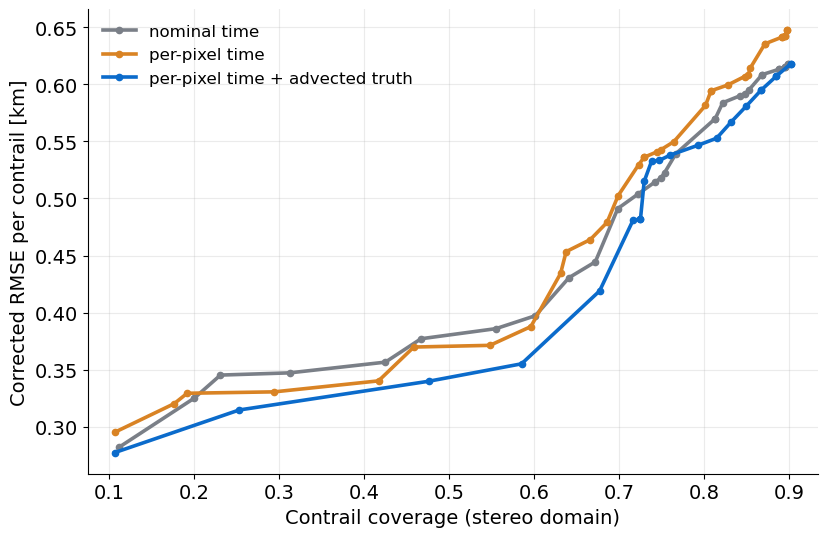

In [12]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

ARMS_PLOT = {   # key in `runs`  ->  (label, colour)
    "nom_raw": ("nominal time", "#7a7f87"),
    "lut_raw": ("per-pixel time", "#d98324"),
    "lut_adv": ("per-pixel time + advected truth", "#0b6bcb"),
}
R_GRID = np.round(np.arange(0.30, 0.86, 0.05), 2)
S_GRID = np.round(np.arange(0.0, 1.51, 0.25), 2)

def sweep(run):
    return pd.DataFrame([dict(r=rg, s_min=sm, **{k: v for k, v in V.contrail_summary(
        run, rg, QC, min_points=MIN_PTS, n_boot=0, s_min=sm).items()
        if k in ("contrail_coverage", "rmse_corr")})
        for sm in S_GRID for rg in R_GRID]).rename(columns={"contrail_coverage": "coverage"})

def pareto(sw):
    d = sw.dropna(subset=["coverage", "rmse_corr"]).sort_values("coverage", ascending=False)
    return d[d.rmse_corr == d.rmse_corr.cummin()].sort_values("coverage")

fronts = {k: pareto(sweep(runs[k])) for k in ARMS_PLOT}

plt.rcParams.update({"font.size": 14, "axes.spines.top": False, "axes.spines.right": False})
fig, ax = plt.subplots(figsize=(8.5, 5.6))
for k, (lab, col) in ARMS_PLOT.items():
    f = fronts[k]
    ax.plot(f.coverage, f.rmse_corr, "-o", color=col, lw=2.6, ms=4.5, label=lab, zorder=3)
ax.set_xlabel("Contrail coverage (stereo domain)")
ax.set_ylabel("Corrected RMSE per contrail [km]")
ax.grid(alpha=0.25); ax.margins(x=0.04)
ax.legend(frameon=False, fontsize=12, loc="upper left")
fig.tight_layout()
fig.savefig(save("gate_tradeoff_arms.pdf") if FIG_DIR else "gate_tradeoff_arms.pdf",
            dpi=200, bbox_inches="tight")

# RMSE of each arm's best combination at fixed coverage (interpolated along its front)
tab = pd.DataFrame({
    lab: {f"cov {t:.1f}": (np.interp(t, fronts[k].coverage, fronts[k].rmse_corr)
                           if fronts[k].coverage.min() <= t <= fronts[k].coverage.max() else np.nan)
          for t in (0.5, 0.6, 0.7)}
    for k, (lab, _) in ARMS_PLOT.items()}).round(3)
print(tab)